In [1]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

from NonParametric import fit_isotonic, predict_isotonic, bootstrap_ci_isotonic
from Parametric import fit_logit_probit, predict_logit_probit, bootstrap_ci_parametric
from Bayesian import fit_bbq, bootstrap_ci_bbq, predict_bbq
from Plots import *
from Data import *
from Evaluation import *

In [ ]:
# data utils
# User Input for Choice of Alzheimers Dataset
def get_dataset_info():
    # Prompt user for dataset choice
    print("Please choose a dataset:")
    print("1. Age group: 55-64 (actual: 55-66.5)")
    print("2. Age group: 65-69 (actual: 62.5-71.5)")
    print("3. Age group: 70-74 (actual: 67.5-76.5)")
    print("4. Age group: 75-79 (actual: 72.5-81.5)")
    print("5. Age group: 80-94 (actual: 77.5-94)")
    dataset_choice = input("Enter your choice (1, 2, 3, 4, 5): ")
    
    # Base path for datasets
    base_path = 'model_reg_calibrations/'
    
    # Choice map of path, dataset name and target value that indicates t=0
    choice_map = {
        '1': (f'{base_path}combined_age_55-64(+2.5)_testdata.csv', 'Age(55_64)', 1),
        '2': (f'{base_path}combined_age_(-2.5)65-69(+2.5)_testdata.csv', 'Age(65_69)', 1),
        '3': (f'{base_path}combined_age_(-2.5)70-74(+2.5)_testdata.csv', 'Age(70_74)', 1),
        '4': (f'{base_path}combined_age_(-2.5)75-79(+2.5)_testdata.csv', 'Age(75_79)', 1),
        '5': (f'{base_path}combined_age_(-2.5)80-94_testdata.csv', 'Age(80_94)', 1)
    }
    
    if dataset_choice in choice_map:
        print(f"Selected dataset: {choice_map[dataset_choice][1]}")
        return choice_map[dataset_choice]
    else:
        raise ValueError(f"Invalid choice: {dataset_choice}. Please choose 1, 2, 3, 4, or 5.")

def load_data(csv_path, target_value):
    # Load the CSV file into a Pandas DataFrame based on the provided path
    df = pd.read_csv(csv_path)

    # Read group information from column index 6
    # Specific encoding: 1=CN (healthy), 3=AD,MCI (alzheimers)
    group = df.iloc[:, 6].to_numpy()

    # Last column is the feature column, that contains the uncalibrated CNN predictions
    X = df.iloc[:, 7].astype(float).to_numpy()

    # Exclude MCI subjects (group=2)
    # mask = group != 2
    # X = X[mask]
    # group = group[mask]

    # Convert to binary: t=0 for healthy (CN), t=1 for alzheimers (AD)
    t = (group == 3).astype(int)
    
    return X, t


In [10]:
def evaluate_methods_as_cnn_calibrators():
    print("Running Mode C: Evaluate Methods as Calibration Models for a CNN on Alzheimers Classification")

    path, dataset_name, target_value = get_dataset_info()

    ''' Data Preparation and Analysis '''
    # Load AIBL dataset
    X, t = load_data(path, target_value)

    # Analyse and Plot Data
    print("Analysing Entire Dataset:")
    analyse_data(X, t, dataset_name)

    ''' Evaluate CNN Model on AIBL Data '''
    # Calculate optimal threshold using Youden's J statistic
    threshold_cnn_all = optimal_threshold_youden(t, X)

    # Predict labels from field specific data using the optimal threshold
    preds_CNN = predict_labels_from_threshold(X, threshold_cnn_all)

    # Evaluate uncalibrated CNN model on the entire dataset
    print("Evaluating Uncalibrated CNN Model on entire dataset:")
    evaluate_uncalibrated_model(t, preds_CNN, X)

    ''' Prepare Data for Calibration Training '''
    # Split Data into Calibration and Testing sets
    # 80% for calibration, 20% for testing
    X_cal, X_test, t_cal, t_test = train_test_split(X, t, test_size=0.2, random_state=42, stratify=t)

    # Sort Train set by X_train
    sorted_indices = np.argsort(X_cal)
    X_cal = X_cal[sorted_indices]
    t_cal = t_cal[sorted_indices]

    # Sort Test set by X_test
    sorted_indices = np.argsort(X_test)
    X_test = X_test[sorted_indices]
    t_test = t_test[sorted_indices]

    ''' Train all Calibration Models '''
    # Regularisation rate
    # TODO: Gridsearch
    lambda_ = 0.0

    # Compute the optimal threshold for the CNN model on the calibration set for comparibility with the other models
    threshold_cnn = optimal_threshold_youden(t_cal, X_cal)

    # Folder to save the trained models
    model_output_folder="../Models_agebins_5yrSplit10yrView_merged/"
    os.makedirs(model_output_folder, exist_ok=True)

    # Logit Regression
    # Confidence Intervals and calibrated predictions as well as best weights
    logit_probs_cal, logit_weights, logit_weights_bootstrap, std_logit = bootstrap_ci_parametric(
        X_cal, t_cal, model_type="logit", n_bootstrap=500, ci=0.95, lambda_=lambda_, seed=42)
    # Determine best threshold for logit model on calibration set
    threshold_logit = optimal_threshold_youden(t_cal, logit_probs_cal)
    # Save all weights for later use to compute prediction and confidence intervals on new data
    params = {f'{dataset_name}_w': logit_weights_bootstrap}
    update_model_file(f'{model_output_folder}logit_models.npz', params)

    # Probit Regression
    # Confidence Intervals and calibrated predictions as well as best weights
    probit_probs_cal, probit_weights, probit_weights_bootstrap, std_probit = bootstrap_ci_parametric(
        X_cal, t_cal, model_type="probit", n_bootstrap=500, ci=0.95, lambda_=lambda_, seed=42)
    # Determine best threshold for probit model on calibration set
    threshold_probit = optimal_threshold_youden(t_cal, probit_probs_cal)
    # Save all weights for later use to compute prediction and confidence intervals on new data
    params = {f'{dataset_name}_w': probit_weights_bootstrap}
    update_model_file(f'{model_output_folder}probit_models.npz', params)

    # Isotonic Regression
    # Confidence Intervals and calibrated predictions
    mean_iso, lower_iso, upper_iso, std_iso = bootstrap_ci_isotonic(
        X_cal.flatten(), t_cal, n_bootstrap=500, ci=0.95, seed=42)
    # Determine best threshold for isotonic model on calibration set
    threshold_iso = optimal_threshold_youden(t_cal, mean_iso)
    # Save all weights for later use to compute prediction and confidence intervals on new data
    params = {f'{dataset_name}_X_cal': X_cal, f'{dataset_name}_y_mean': mean_iso, f'{dataset_name}_y_lower': lower_iso, f'{dataset_name}_y_upper': upper_iso}
    update_model_file(f'{model_output_folder}iso_models.npz', params)

    # BBQ Calibration
    # Confidence Intervals and calibrated predictions
    mean_bbq, lower_bbq, upper_bbq, std_bbq = bootstrap_ci_bbq(
        X_cal.flatten(), t_cal, n_bootstrap=500, ci=0.95, seed=42)
    # Determine best threshold for bbq model on calibration set
    threshold_bbq = optimal_threshold_youden(t_cal, mean_bbq)
    # Fit BBQ Calibration and get bin edges, means and model weights
    _, bin_edges_list, bin_means_list, bbq_weights = fit_bbq(X_cal.flatten(), t_cal)
    # Save all weights for later use to compute prediction and confidence intervals on new data
    params = {
        f'{dataset_name}_X_train': X_cal,         # shape (n_samples,)
        f'{dataset_name}_y_mean': mean_bbq,       # shape (n_samples,)
        f'{dataset_name}_y_lower': lower_bbq,     # shape (n_samples,)
        f'{dataset_name}_y_upper': upper_bbq      # shape (n_samples,)
    }
    update_model_file(f'{model_output_folder}bbq_models.npz', params)

    ''' Print Metrics for Goodness of Fit of the Base Model and Calibration Models (Classification and Calibration context) '''
    # print optimal thresholds for all models
    print("Optimal Thresholds for all Models:")
    print(f"Optimal Threshold for CNN Model: {threshold_cnn}")
    print(f"Optimal Threshold for Logit Model: {threshold_logit}")
    print(f"Optimal Threshold for Probit Model: {threshold_probit}")
    print(f"Optimal Threshold for Isotonic Model: {threshold_iso}")
    print(f"Optimal Threshold for BBQ Model: {threshold_bbq}")

    # print standard deviations of the predicted probabilities for all models
    print("Standard Deviations of Predicted Probabilities for all Models:")
    print(f"Mean Standard Deviation by point for Logit Model: {std_logit}")
    print(f"Mean Standard Deviation by point for Probit Model: {std_probit}")
    print(f"Mean Standard Deviation by point for Isotonic Model: {std_iso}")
    print(f"Mean Standard Deviation by point for BBQ Model: {std_bbq}")

    # get CNN predictions on the test set
    preds_CNN_test = predict_labels_from_threshold(X_test, threshold_cnn)

    # Classification Metrics (Accuracy, F1-Score)
    print("Evaluating all Models as Classifiers on testdata:")
    evaluate_as_classifier(X_test, t_test, threshold_logit, threshold_probit, threshold_iso, threshold_bbq,
                           logit_weights, probit_weights, X_cal, mean_iso, bin_edges_list, bin_means_list, bbq_weights,
                           X_real=X_test, t_cnn=preds_CNN_test)

    # Calibration Metrics (Log-Loss, Brier Score, ECE, MCE)
    print("Evaluating all Models as Calibrators on testdata:")
    evaluate_as_calibrator(X_test, t_test,
                           logit_weights, probit_weights, X_cal, mean_iso, bin_edges_list, bin_means_list, bbq_weights,
                           X_real=X_test)

    # Evaluate uncalibrated CNN model on the test set
    # print("Evaluating Uncalibrated CNN Model on testdata:")
    # evaluate_uncalibrated_model(t_test, preds_CNN_test, X_test)

    ''' Plot all Models against each other '''
    # Plot preds for Logit, Probit and Isotonic Regression on Train Set
    plot_probabilistic_prediction_all(X_cal, logit_weights, probit_weights, mean_iso, mean_bbq)

    # Plot preds for Logit, Probit and Isotonic Regression on Train Set with data displayed
    plot_probabilistic_prediction_all_with_data(X_cal, t_cal, logit_weights, probit_weights, mean_iso, mean_bbq)

    ''' Plot all Models with their respective confidence intervals using bootstrapping '''
    # Plot all Calibration Curves in one plot as well as each of them with their respective confidence intervals
    plot_probabilistic_prediction_all_with_ci_bootstrap(
        X_cal,
        logit_weights_bootstrap,
        probit_weights_bootstrap,
        mean_iso, lower_iso, upper_iso,
        mean_bbq, lower_bbq, upper_bbq,
        alpha=0.05,
        grid_size=500,
        gap_threshold=0.05
    )

    ''' Plot Calibration Curves on Test Set'''
    # Calculate predicted probabilities for the Calibration Curve
    logit_probs_test = predict_logit_probit(X_test, logit_weights, model_type="logit")
    probit_probs_test = predict_logit_probit(X_test, probit_weights, model_type="probit")
    isotonic_probs_test = predict_isotonic(X_cal, mean_iso, X_test)
    bbq_probs_test = predict_bbq(X_test.flatten(), bin_edges_list, bin_means_list, bbq_weights)

    # Plot Calibration Curves for all three models
    plot_calibration_curve(t_test, logit_probs_test, probit_probs_test, isotonic_probs_test, bbq_probs_test, X_test)

    # Plot Residuals - this offers no new insights, but is kept in for consistency but commented out
    # plot_binned_residuals(t_test, logit_probs_test, probit_probs_test, isotonic_probs_test, bbq_probs_test)


## Age Group: 55-64

Running Mode C: Evaluate Methods as Calibration Models for a CNN on Alzheimers Classification
Please choose a dataset:
1. Age group: 55-64 (actual: 55-66.5)
2. Age group: 65-69 (actual: 62.5-71.5)
3. Age group: 70-74 (actual: 67.5-76.5)
4. Age group: 75-79 (actual: 72.5-81.5)
5. Age group: 80-94 (actual: 77.5-94)
Selected dataset: Age(55_64)
Analysing Entire Dataset:
Summary statistics:
                X           t
count  361.000000  361.000000
mean     0.410751    0.299169
std      0.315795    0.458530
min      0.040722    0.000000
25%      0.160268    0.000000
50%      0.282961    0.000000
75%      0.656552    1.000000
max      1.000000    1.000000

Label-wise mean of X:
t
0    0.301882
1    0.665788
Name: X, dtype: float64


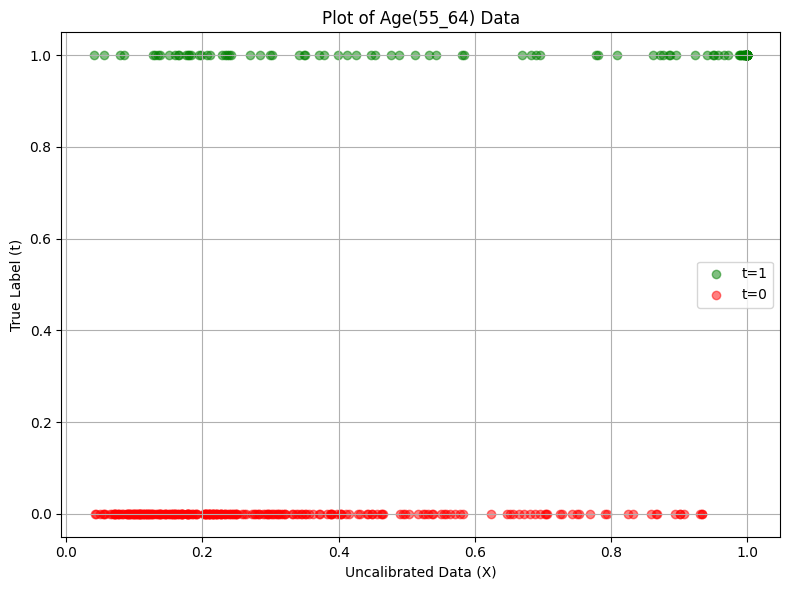

Evaluating Uncalibrated CNN Model on entire dataset:
Uncalibrated CNN Performance:
Accuracy:       0.8227
F1 Score:       0.6444
Log Loss:       0.5087
Brier Score:    0.1690
ECE (Expected): 0.1359
MCE (Max):      0.5821
Optimal Thresholds for all Models:
Optimal Threshold for CNN Model: 0.7778759
Optimal Threshold for Logit Model: 0.5965401264508932
Optimal Threshold for Probit Model: 0.6006461153049786
Optimal Threshold for Isotonic Model: 0.3311592271899572
Optimal Threshold for BBQ Model: 0.2664403064191547
Standard Deviations of Predicted Probabilities for all Models:
Mean Standard Deviation by point for Logit Model: 0.032378746438484124
Mean Standard Deviation by point for Probit Model: 0.032544279274293805
Mean Standard Deviation by point for Isotonic Model: 0.056661121464696325
Mean Standard Deviation by point for BBQ Model: 0.09622273560028437
Evaluating all Models as Classifiers on testdata:

Differing sample indices between Logit and Probit (needed for DELCODE): [56]

Index:

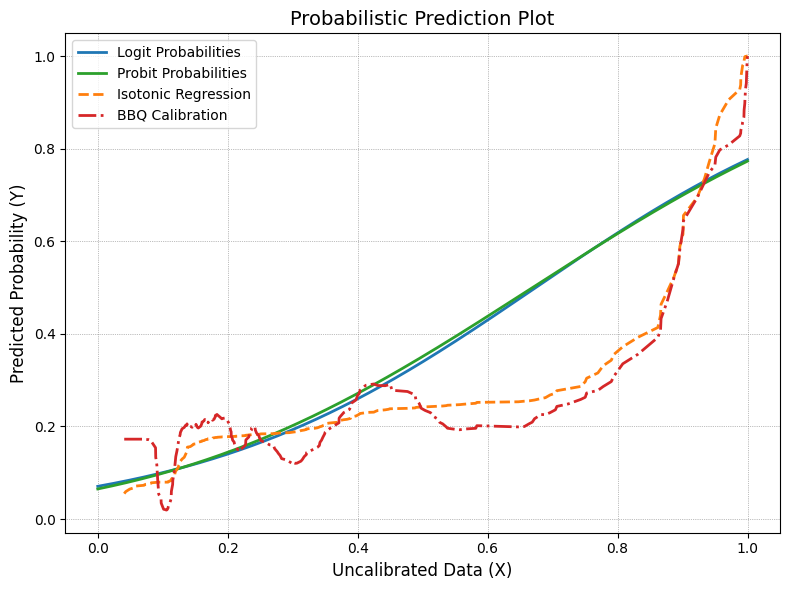

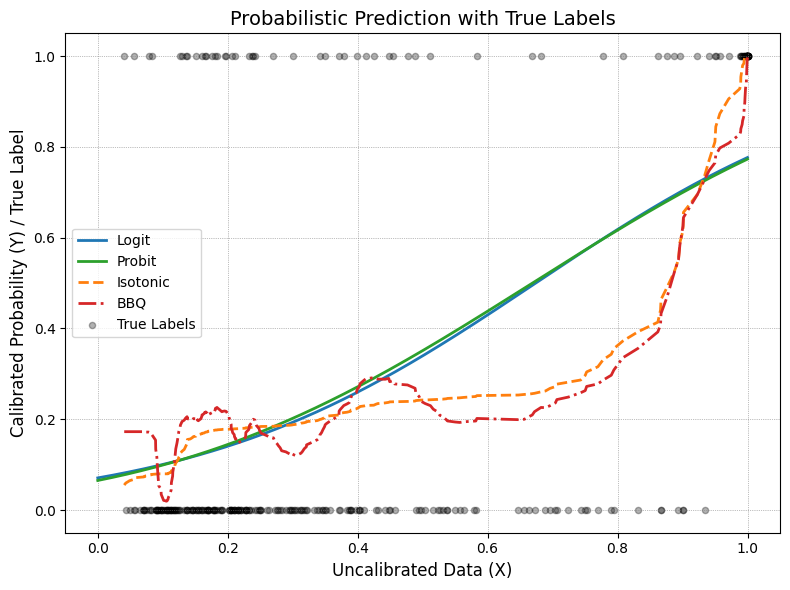

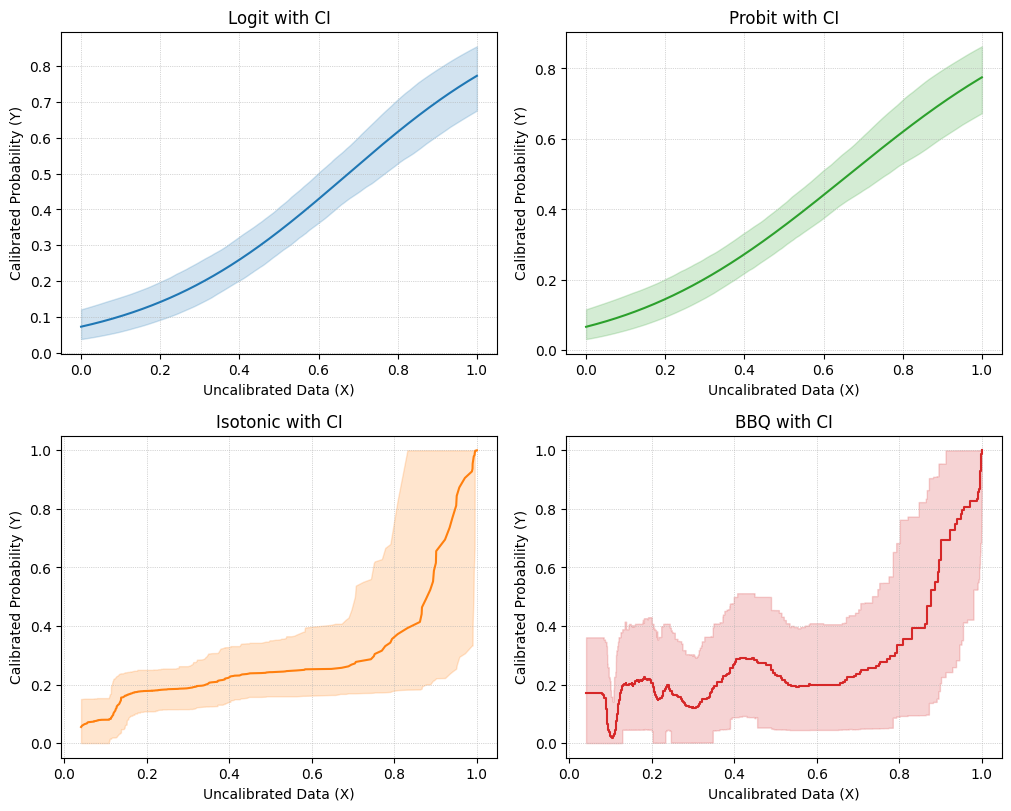

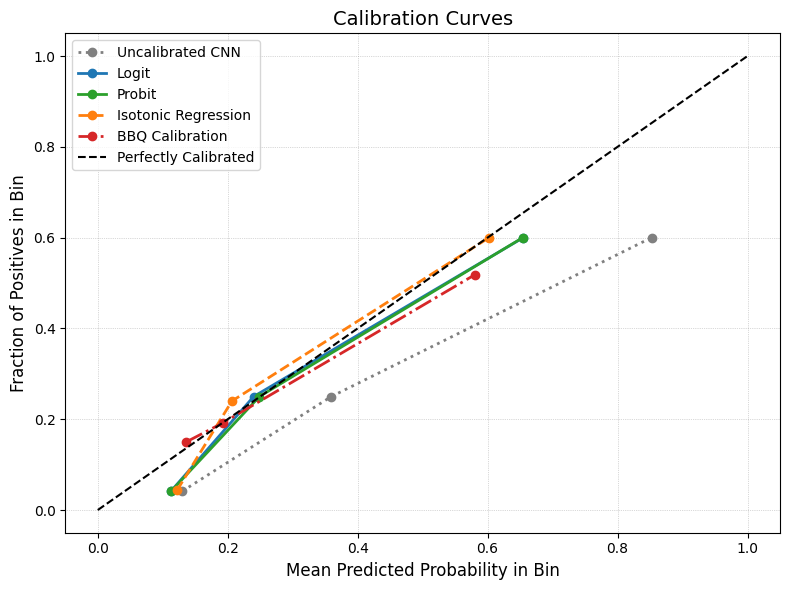

In [11]:
evaluate_methods_as_cnn_calibrators()

## Age Group: 65-69

Running Mode C: Evaluate Methods as Calibration Models for a CNN on Alzheimers Classification
Please choose a dataset:
1. Age group: 55-64 (actual: 55-66.5)
2. Age group: 65-69 (actual: 62.5-71.5)
3. Age group: 70-74 (actual: 67.5-76.5)
4. Age group: 75-79 (actual: 72.5-81.5)
5. Age group: 80-94 (actual: 77.5-94)
Selected dataset: Age(65_69)
Analysing Entire Dataset:
Summary statistics:
                X          t
count  689.000000  689.00000
mean     0.399680    0.28447
std      0.317642    0.45149
min      0.037635    0.00000
25%      0.142324    0.00000
50%      0.266701    0.00000
75%      0.624191    1.00000
max      1.000000    1.00000

Label-wise mean of X:
t
0    0.294582
1    0.664034
Name: X, dtype: float64


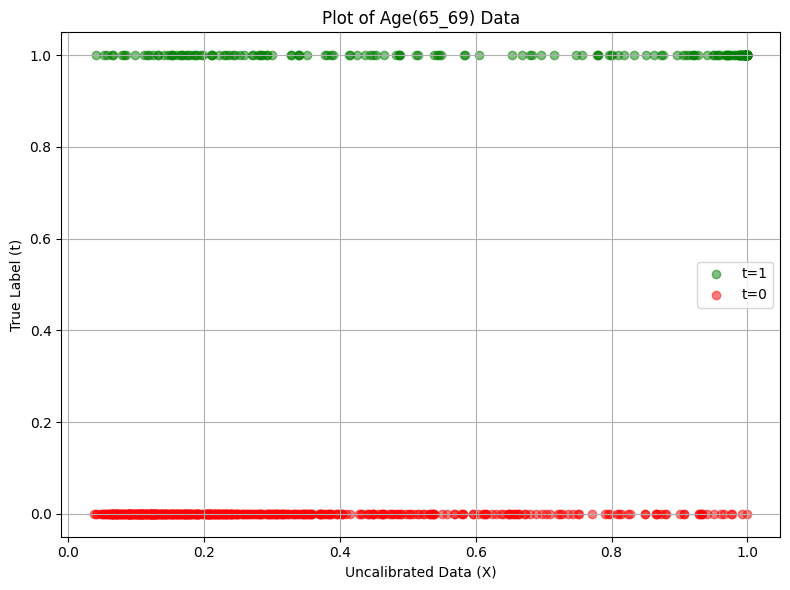

Evaluating Uncalibrated CNN Model on entire dataset:
Uncalibrated CNN Performance:
Accuracy:       0.8099
F1 Score:       0.6310
Log Loss:       0.5280
Brier Score:    0.1672
ECE (Expected): 0.1312
MCE (Max):      0.4118
Optimal Thresholds for all Models:
Optimal Threshold for CNN Model: 0.6687088
Optimal Threshold for Logit Model: 0.4545120869376059
Optimal Threshold for Probit Model: 0.46393440777397915
Optimal Threshold for Isotonic Model: 0.29228677904556755
Optimal Threshold for BBQ Model: 0.26423931970083275
Standard Deviations of Predicted Probabilities for all Models:
Mean Standard Deviation by point for Logit Model: 0.022070686621500683
Mean Standard Deviation by point for Probit Model: 0.022252490304015406
Mean Standard Deviation by point for Isotonic Model: 0.04517732585432474
Mean Standard Deviation by point for BBQ Model: 0.08833126771330341
Evaluating all Models as Classifiers on testdata:

Differing sample indices between Logit and Probit (needed for DELCODE): []
Classif

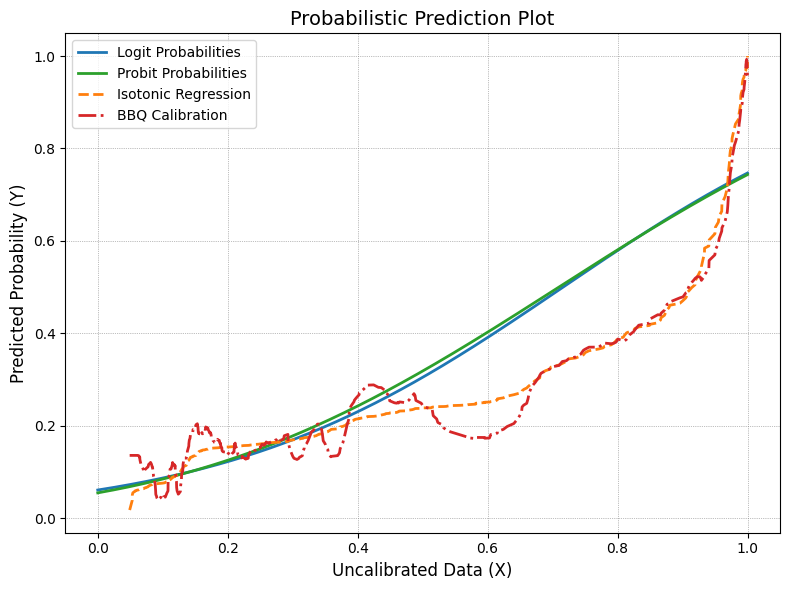

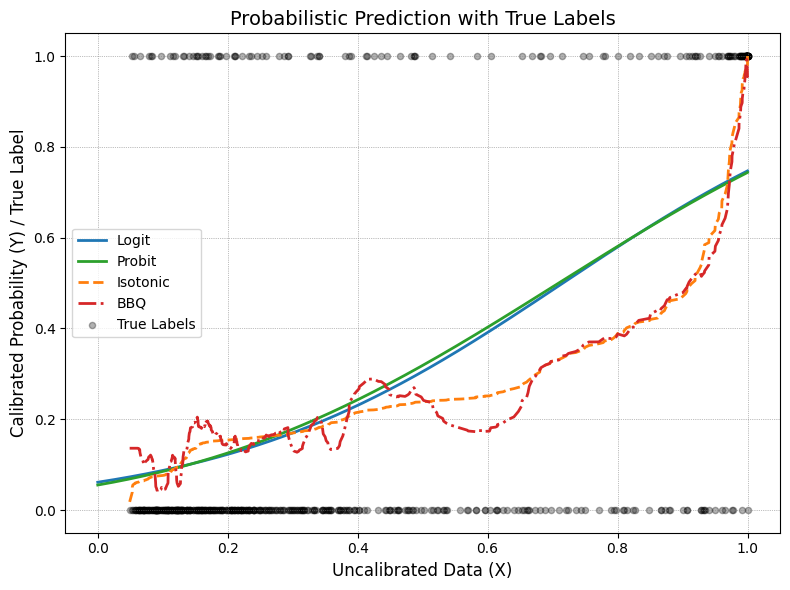

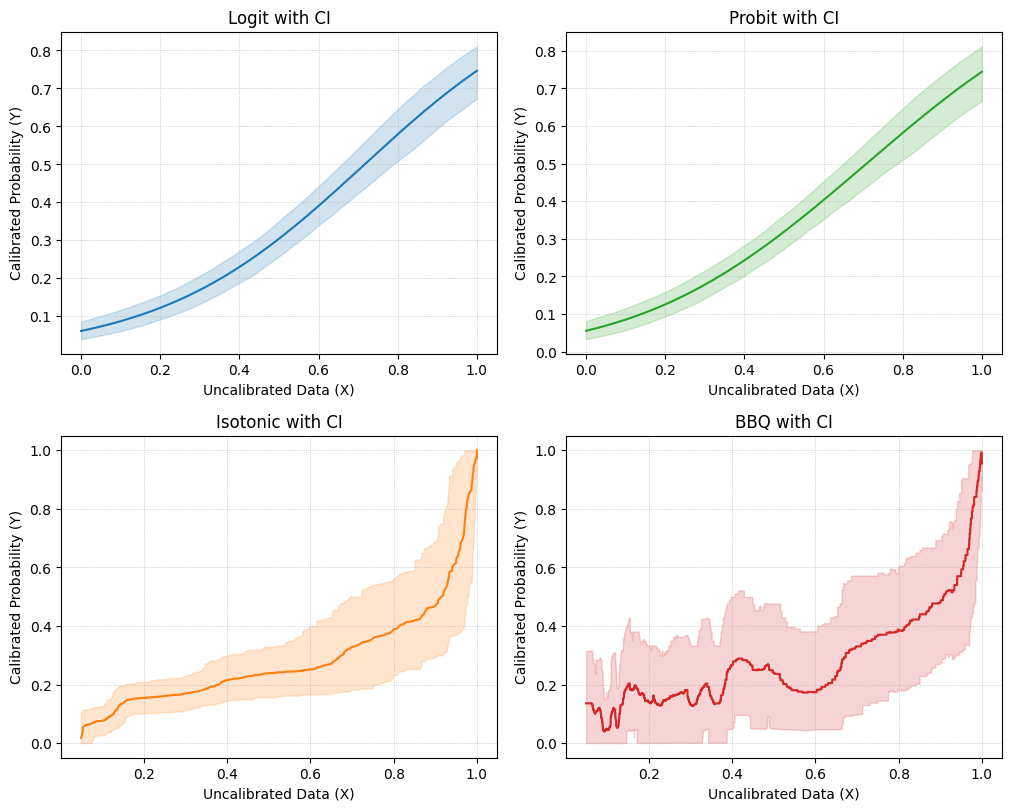

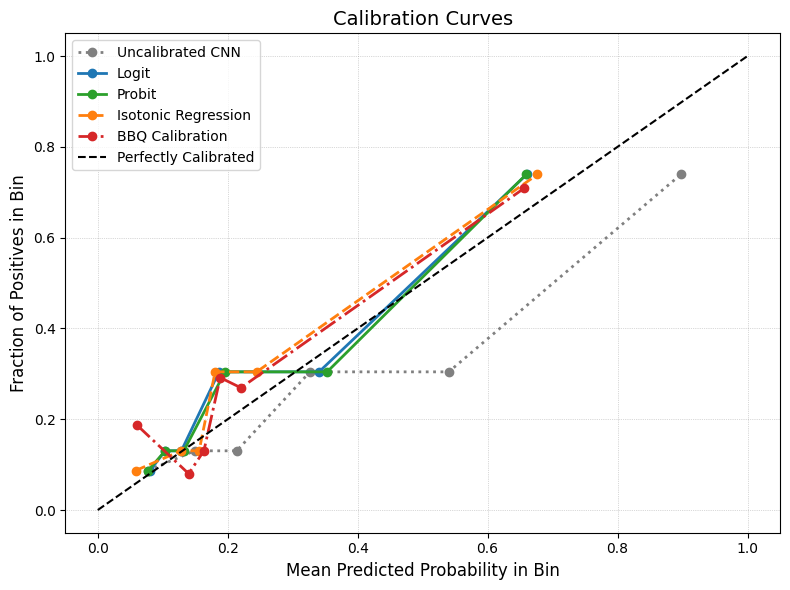

In [12]:
evaluate_methods_as_cnn_calibrators()

## Age Group: 70-74

Running Mode C: Evaluate Methods as Calibration Models for a CNN on Alzheimers Classification
Please choose a dataset:
1. Age group: 55-64 (actual: 55-66.5)
2. Age group: 65-69 (actual: 62.5-71.5)
3. Age group: 70-74 (actual: 67.5-76.5)
4. Age group: 75-79 (actual: 72.5-81.5)
5. Age group: 80-94 (actual: 77.5-94)
Selected dataset: Age(70_74)
Analysing Entire Dataset:
Summary statistics:
                X           t
count  787.000000  787.000000
mean     0.445348    0.385006
std      0.336813    0.486906
min      0.029508    0.000000
25%      0.148203    0.000000
50%      0.323773    0.000000
75%      0.769918    1.000000
max      1.000000    1.000000

Label-wise mean of X:
t
0    0.298586
1    0.679778
Name: X, dtype: float64


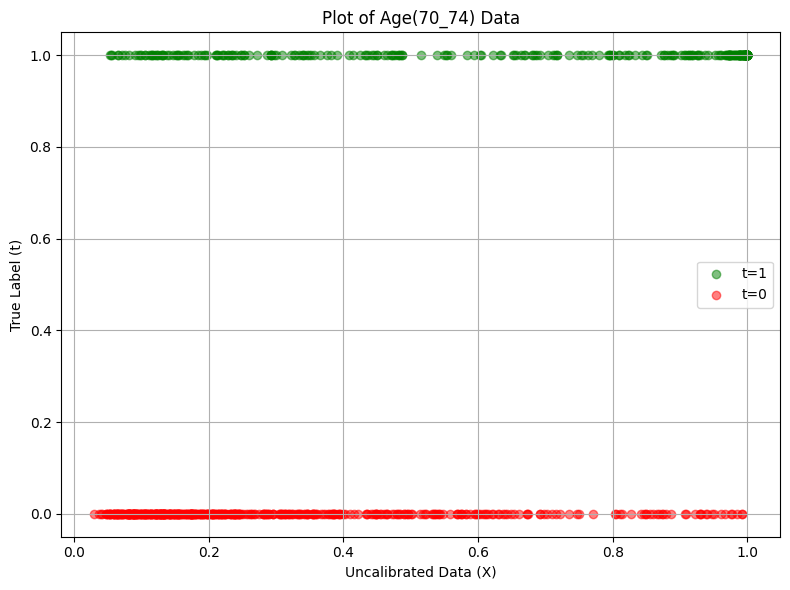

Evaluating Uncalibrated CNN Model on entire dataset:
Uncalibrated CNN Performance:
Accuracy:       0.7853
F1 Score:       0.6853
Log Loss:       0.5312
Brier Score:    0.1732
ECE (Expected): 0.0919
MCE (Max):      0.3956
Optimal Thresholds for all Models:
Optimal Threshold for CNN Model: 0.6525477
Optimal Threshold for Logit Model: 0.5489946601831016
Optimal Threshold for Probit Model: 0.5525375836681174
Optimal Threshold for Isotonic Model: 0.41966871660214694
Optimal Threshold for BBQ Model: 0.3174041950807823
Standard Deviations of Predicted Probabilities for all Models:
Mean Standard Deviation by point for Logit Model: 0.02228372681022211
Mean Standard Deviation by point for Probit Model: 0.022143898367283536
Mean Standard Deviation by point for Isotonic Model: 0.04766624479600258
Mean Standard Deviation by point for BBQ Model: 0.09477585381844662
Evaluating all Models as Classifiers on testdata:

Differing sample indices between Logit and Probit (needed for DELCODE): []
Classifier

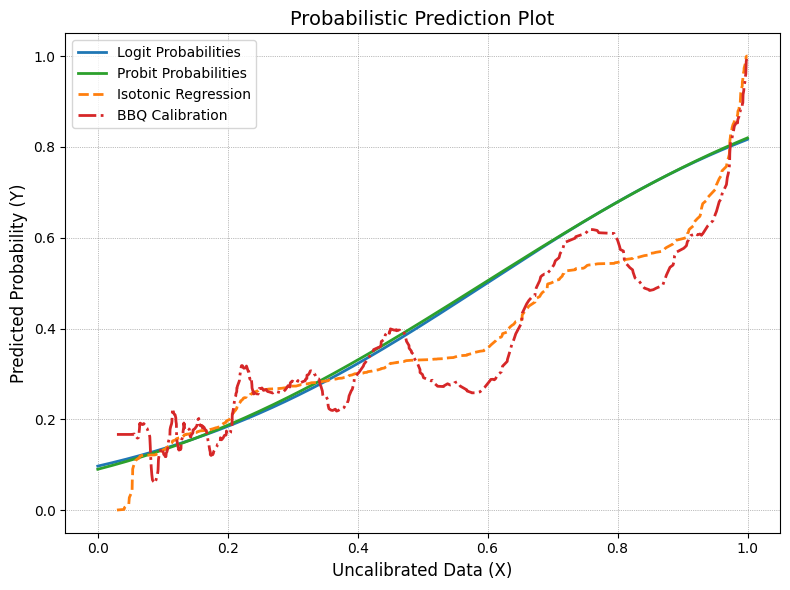

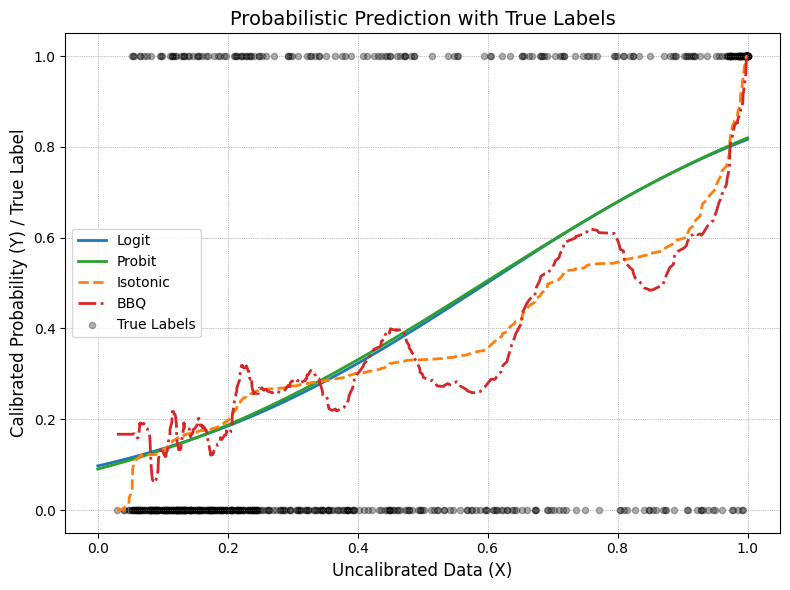

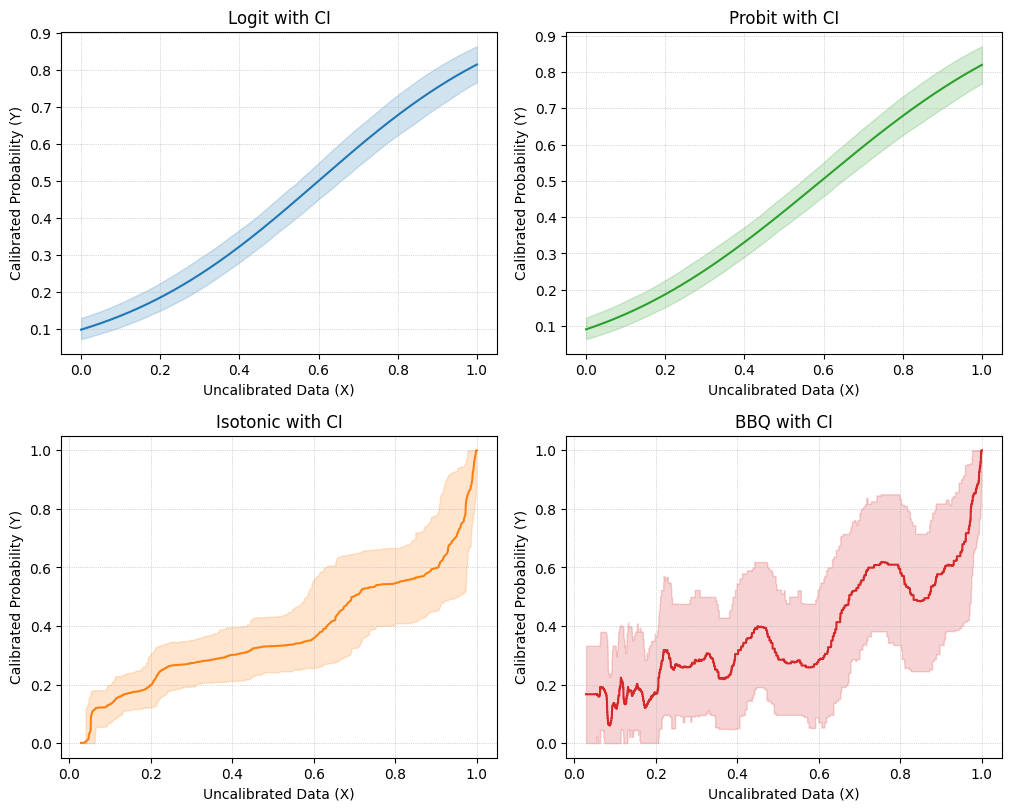

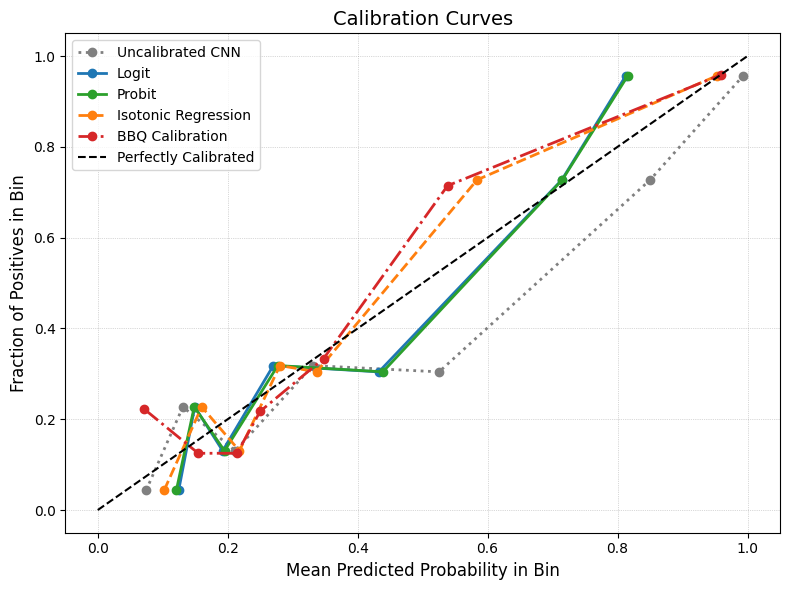

In [13]:
evaluate_methods_as_cnn_calibrators()

## Age Group: 75-79

Running Mode C: Evaluate Methods as Calibration Models for a CNN on Alzheimers Classification
Please choose a dataset:
1. Age group: 55-64 (actual: 55-66.5)
2. Age group: 65-69 (actual: 62.5-71.5)
3. Age group: 70-74 (actual: 67.5-76.5)
4. Age group: 75-79 (actual: 72.5-81.5)
5. Age group: 80-94 (actual: 77.5-94)
Selected dataset: Age(75_79)
Analysing Entire Dataset:
Summary statistics:
                X           t
count  630.000000  630.000000
mean     0.497872    0.500000
std      0.349164    0.500397
min      0.041074    0.000000
25%      0.167593    0.000000
50%      0.383517    0.500000
75%      0.892588    1.000000
max      0.999999    1.000000

Label-wise mean of X:
t
0    0.294177
1    0.701567
Name: X, dtype: float64


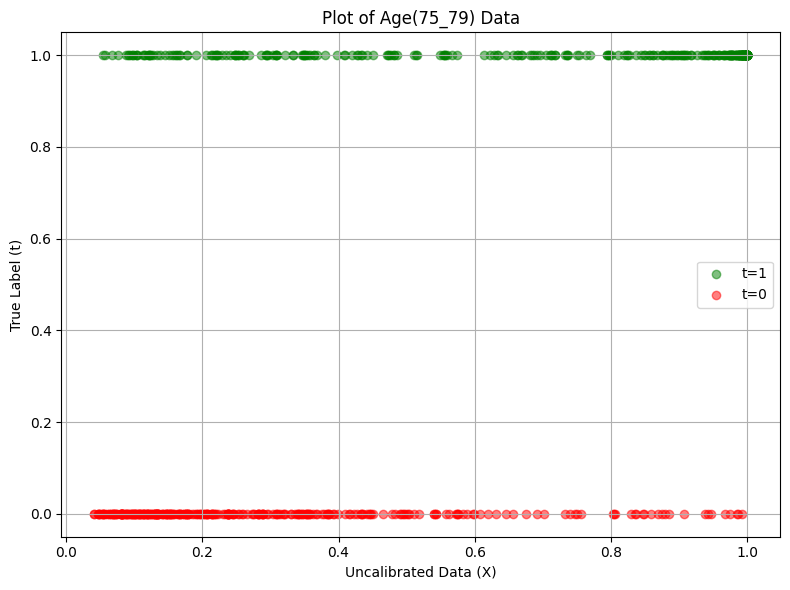

Evaluating Uncalibrated CNN Model on entire dataset:
Uncalibrated CNN Performance:
Accuracy:       0.7730
F1 Score:       0.7414
Log Loss:       0.5101
Brier Score:    0.1680
ECE (Expected): 0.0701
MCE (Max):      0.1804
Optimal Thresholds for all Models:
Optimal Threshold for CNN Model: 0.6225076
Optimal Threshold for Logit Model: 0.6359730980077496
Optimal Threshold for Probit Model: 0.6328055353918715
Optimal Threshold for Isotonic Model: 0.537534309222821
Optimal Threshold for BBQ Model: 0.4569102444471993
Standard Deviations of Predicted Probabilities for all Models:
Mean Standard Deviation by point for Logit Model: 0.024847121210503656
Mean Standard Deviation by point for Probit Model: 0.024560835565869982
Mean Standard Deviation by point for Isotonic Model: 0.05345411049622533
Mean Standard Deviation by point for BBQ Model: 0.09698410779839399
Evaluating all Models as Classifiers on testdata:

Differing sample indices between Logit and Probit (needed for DELCODE): []
Classifier 

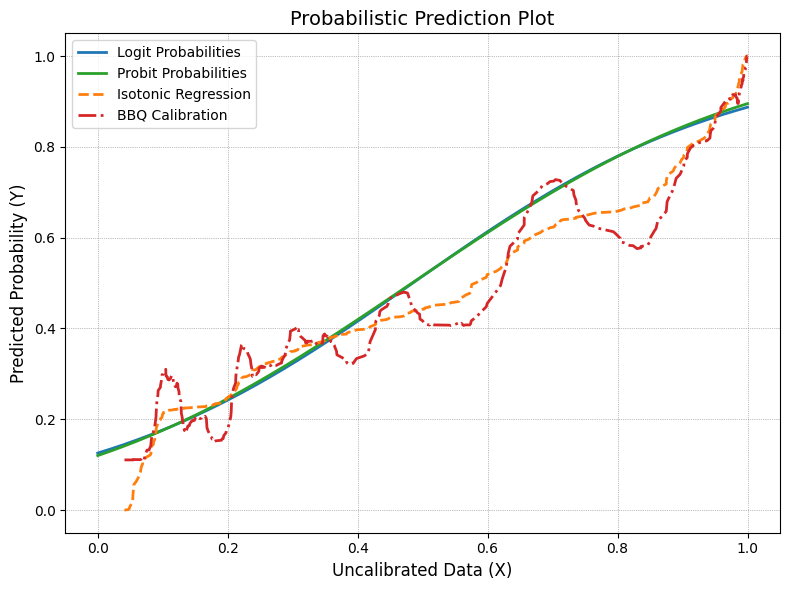

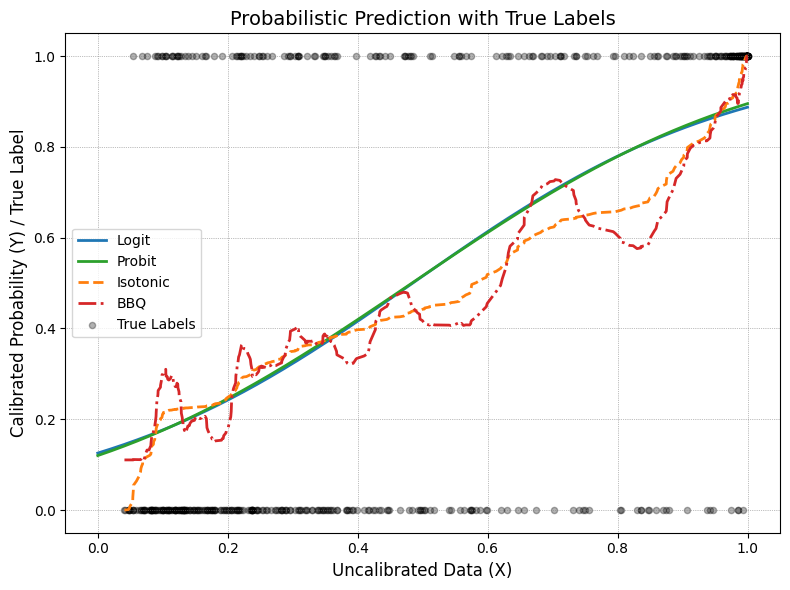

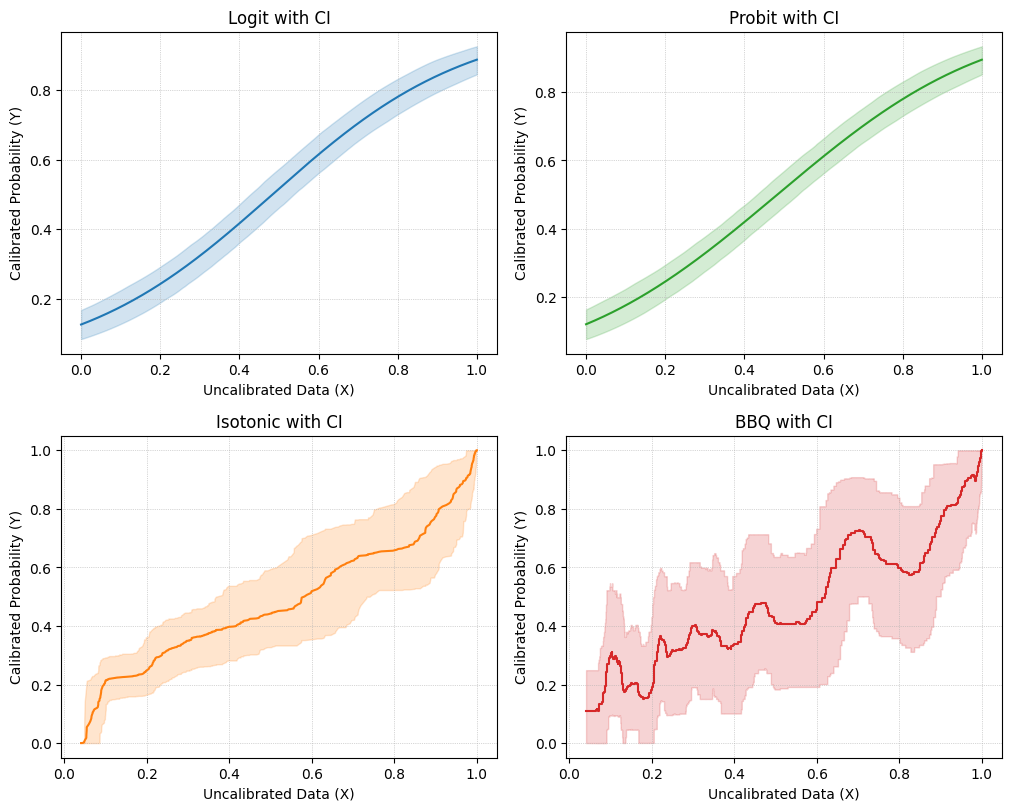

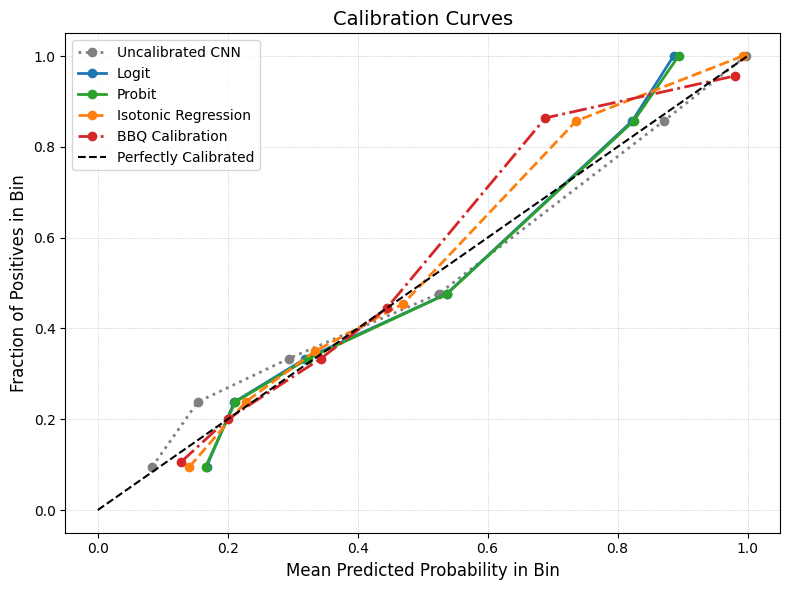

In [14]:
evaluate_methods_as_cnn_calibrators()

## Age Group: 80-94

Running Mode C: Evaluate Methods as Calibration Models for a CNN on Alzheimers Classification
Please choose a dataset:
1. Age group: 55-64 (actual: 55-66.5)
2. Age group: 65-69 (actual: 62.5-71.5)
3. Age group: 70-74 (actual: 67.5-76.5)
4. Age group: 75-79 (actual: 72.5-81.5)
5. Age group: 80-94 (actual: 77.5-94)
Selected dataset: Age(80_94)
Analysing Entire Dataset:
Summary statistics:
                X           t
count  363.000000  363.000000
mean     0.523607    0.570248
std      0.356668    0.495724
min      0.032880    0.000000
25%      0.176007    0.000000
50%      0.423136    1.000000
75%      0.943185    1.000000
max      0.999999    1.000000

Label-wise mean of X:
t
0    0.296323
1    0.694894
Name: X, dtype: float64


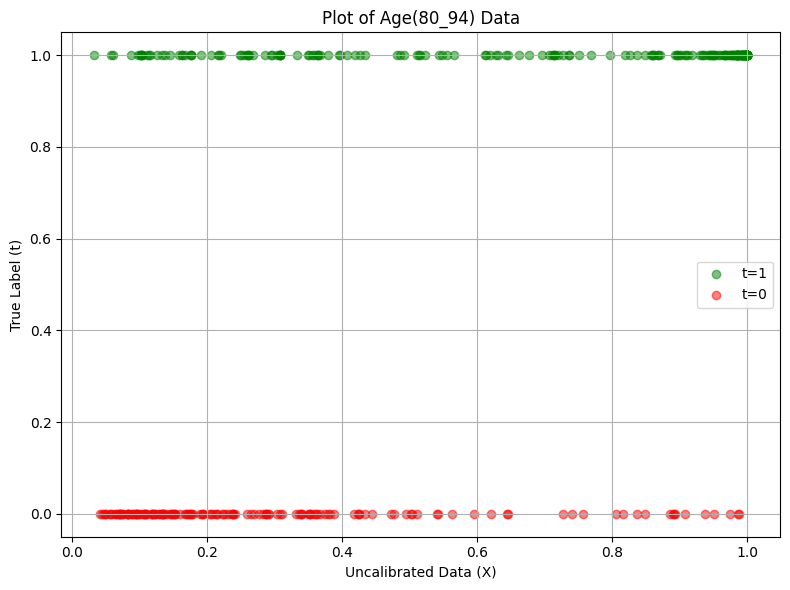

Evaluating Uncalibrated CNN Model on entire dataset:
Uncalibrated CNN Performance:
Accuracy:       0.7548
F1 Score:       0.7614
Log Loss:       0.5390
Brier Score:    0.1788
ECE (Expected): 0.0954
MCE (Max):      0.2227
Optimal Thresholds for all Models:
Optimal Threshold for CNN Model: 0.51063836
Optimal Threshold for Logit Model: 0.6096974181534548
Optimal Threshold for Probit Model: 0.6015624142866249
Optimal Threshold for Isotonic Model: 0.6059831604326096
Optimal Threshold for BBQ Model: 0.5792952653585273
Standard Deviations of Predicted Probabilities for all Models:
Mean Standard Deviation by point for Logit Model: 0.03299581529750355
Mean Standard Deviation by point for Probit Model: 0.032687910807838866
Mean Standard Deviation by point for Isotonic Model: 0.06637025062482935
Mean Standard Deviation by point for BBQ Model: 0.09404844871322138
Evaluating all Models as Classifiers on testdata:

Differing sample indices between Logit and Probit (needed for DELCODE): []
Classifier

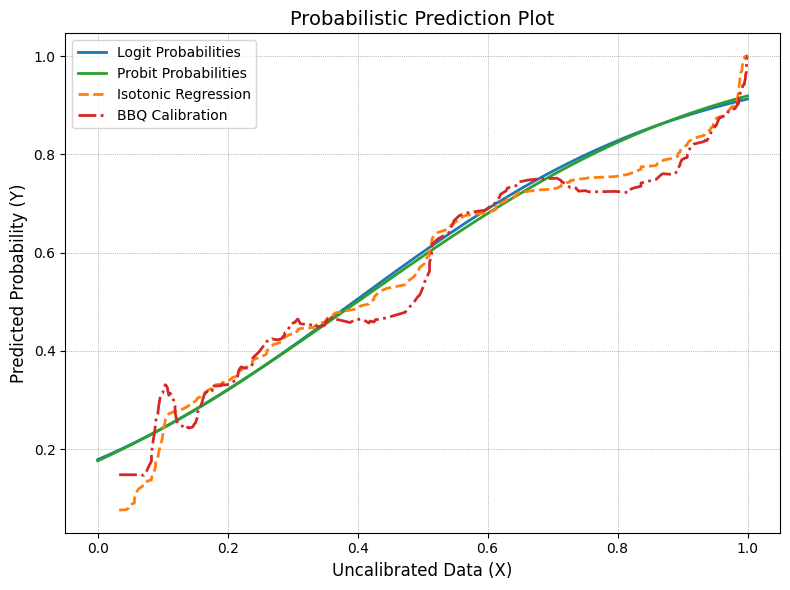

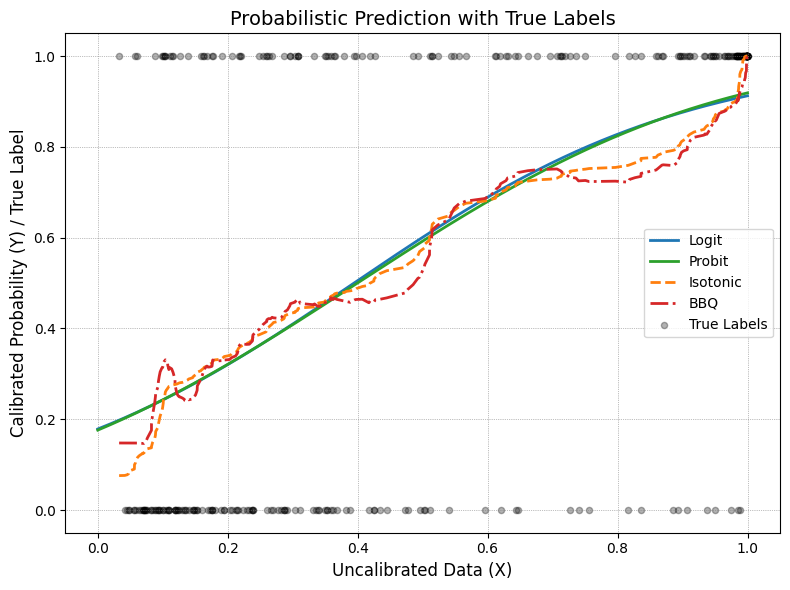

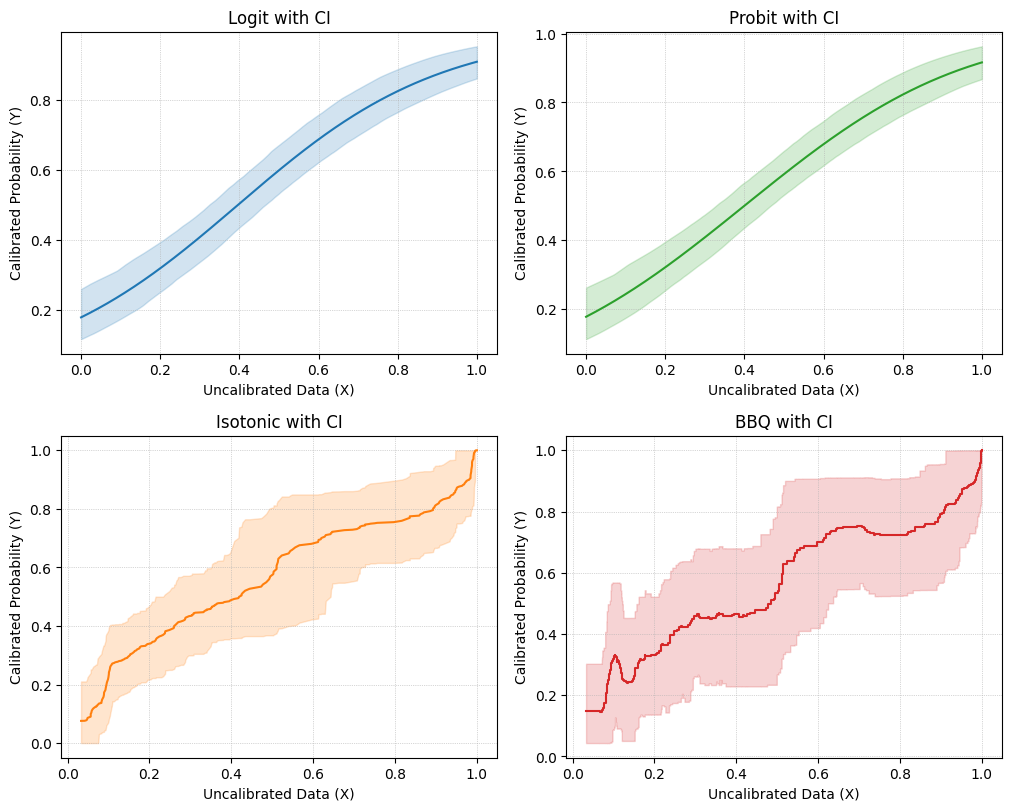

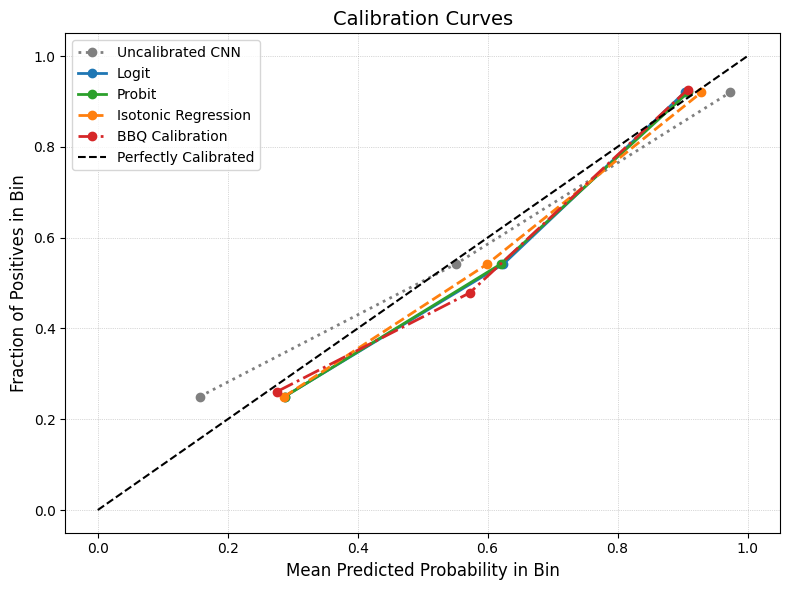

In [15]:
evaluate_methods_as_cnn_calibrators()

In [ ]:
import nbconvert
from nbconvert import HTMLExporter
import nbformat

# Read the notebook
with open('Operation_agebins_5yrSplitsMerged_calibration_mitMCI_ohneADNI2.ipynb', 'r') as f:
    notebook = nbformat.read(f, as_version=4)

# Convert to HTML
html_exporter = HTMLExporter()
body, resources = html_exporter.from_notebook_node(notebook)

# Write the HTML file
with open('Operation_agebins_5yrSplitsMerged_calibration_mitMCI_ohneADNI2.html', 'w') as f:
    f.write(body)